In [1]:
# !pip install segmentation-models-pytorch
# !pip install torchmetrics
# !pip install mlflow[databricks]

In [2]:
import os

# Replace with your actual workspace URL and token
# os.environ['DATABRICKS_HOST'] = ""
# os.environ['DATABRICKS_TOKEN'] = ""


In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupKFold

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

# from torchmetrics.segmentation import DiceScore
# from torchmetrics.segmentation import MeanIoU

from tqdm import tqdm
import json

# Configurar el dispositivo (GPU si está disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def build_color_map_from_json(label_dict):
    color_map_raw = label_dict["mascara_multiclase_color_rgb"]
    return {int(k): tuple(v) for k, v in color_map_raw.items()}

def build_label_map_from_json(label_dict):
    label_map_raw = label_dict["mascara_multiclase_id_png"]
    return {int(k): v for k, v in label_map_raw.items()}

def create_color_overlay(mask, color_map, alpha=0.45):
    h, w = mask.shape
    overlay = np.zeros((h, w, 3), dtype=np.uint8)

    for class_id, color in color_map.items():
        overlay[mask == class_id] = color

    return overlay

def get_class_centroid(mask, class_id):
    ys, xs = np.where(mask == class_id)
    if len(xs) == 0 or len(ys) == 0:
        return None
    cx = int(np.mean(xs))
    cy = int(np.mean(ys))
    return cx, cy

def show_overlay_with_labels(image, mask, label_dict, alpha=0.45, min_pixels=20):
    label_map = build_label_map_from_json(label_dict)
    color_map = build_color_map_from_json(label_dict)

    # image = cv2.imread(image_path)
    # image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

    overlay = create_color_overlay(mask, color_map, alpha=alpha)

    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.imshow(overlay, alpha=alpha)

    unique_vals = np.unique(mask)

    for class_id in unique_vals:
        if class_id == 0:
            continue

        region = (mask == class_id)
        if region.sum() < min_pixels:
            continue

        centroid = get_class_centroid(mask, class_id)
        if centroid is None:
            continue

        x, y = centroid
        class_name = label_map.get(int(class_id), str(class_id))

        plt.text(
            x, y, class_name,
            fontsize=9,
            ha="center",
            va="center",
            color="white",
            bbox=dict(facecolor="black", alpha=0.6, boxstyle="round,pad=0.2")
        )

    plt.title("Overlay con clases anatómicas")
    plt.axis("off")
    plt.show()

In [5]:
# from google.colab import drive
# drive.mount('/content/drive')

In [6]:
# dataset = '/content/drive/MyDrive/Documentos/UniAndes/MAIA/2026-12/Proyecto Despluiegue de Soluciones/Proyecto/Scoliosis_Dataset'
# indice = pd.read_csv(os.path.join(dataset,'indice_dataset.csv'))

In [7]:
# dataset = 'Scoliosis_Dataset'
project_path = 'C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA'
dataset_version = 'Scoliosis_Dataset_v2'
dataset = os.path.join(project_path, dataset_version)
indice = pd.read_csv('indice_completas.csv')
normal = indice[indice['grupo']=='Normal']
esc = indice[indice['grupo']=='Scoliosis']

In [8]:
with open(dataset+os.sep+'diccionario_etiquetas_T1_T12_L1_L5.json', 'r') as f:
    dic_labels = json.load(f)

color_label = dic_labels['mascara_multiclase_color_rgb']

In [9]:
# Split: 80% entrenamiento, 10% validación y 10% prueba
train_normal, test_normal = train_test_split(
    normal, test_size=0.1, random_state=42
)

train_normal, val_normal = train_test_split(
    train_normal, test_size=0.1, random_state=42
)

train_esc, test_esc = train_test_split(
    esc, test_size=0.1, random_state=42
)

train_esc, val_esc = train_test_split(
    train_esc, test_size=0.1, random_state=42
)

train = pd.concat([train_normal, train_esc])
train['split'] = 'train'
val = pd.concat([val_normal, val_esc])
val['split'] = 'val'
test = pd.concat([test_normal, test_esc])
test['split'] = 'test'

data_split = pd.concat([train, val, test])

In [10]:
data_split['image_relpath']=dataset_version+os.sep+data_split['ruta_radiografia']
data_split['mask_relpath']=dataset_version+os.sep+data_split['ruta_mascara_multiclase_id_png']

In [11]:
# imagenes = pd.DataFrame(columns=['image_path', 'mask_path', 'id_paciente'])
# imagenes['image_path'] = dataset +os.sep + indice['grupo'] + os.sep + indice['imagen']
# imagenes['mask_path'] = dataset + os.sep + indice['ruta_mascara_multiclase_id_png']
# imagenes['id_paciente'] = indice['id_paciente']
# masks_path = masks_path.apple(dataset, indice['grupo'], indice['ruta_mascara_multiclase_id_png'])

In [12]:
# imagenes

In [13]:
train = data_split[data_split['split'] == 'train']
val = data_split[data_split['split'] == 'val']
test = data_split[data_split['split'] == 'test']

In [14]:
train_img = project_path+os.sep+train['image_relpath'].reset_index(drop=True)
train_mask = project_path+os.sep+train['mask_relpath'].reset_index(drop=True)
val_img = project_path+os.sep+val['image_relpath'].reset_index(drop=True)
val_mask = project_path+os.sep+val['mask_relpath'].reset_index(drop=True)
test_img = project_path+os.sep+test['image_relpath'].reset_index(drop=True)
test_mask = project_path+os.sep+test['mask_relpath'].reset_index(drop=True)

In [15]:
print(f'Train: {train_img.shape} Val: {val_img.shape} Test: {test_img.shape}')

Train: (60,) Val: (8,) Test: (8,)


In [16]:
MODEL_NAME = 'Unet++'
MODEL_PATH = 'modelos'+os.sep+MODEL_NAME+'_completas'+'.pth'
SEED = 42
NUM_EPOCHS = 250
BATCH_SIZE = 2
PATIENCE = 50
N_SPLITS = 4
LR = 1e-3                   # Learning rate
WD = 1e-4                  # Weight Decay
DROPOUT = 0.2
IMG_SIZE = (480, 480)
IN_CHANNELS = 3
NUM_CLASSES = 18
TRAIN_ENCODER = True
CENTER_IMAGES = True
CLAHE = True
PERSPECTIVE = True

# LOSS = 'CrossEntropyLoss'
# LOSS = 'CombinedLoss'
LOSS = 'CombinedLossFocal'
# LOSS = 'DiceLoss'

# ENCODER_NAME = "resnet34"
# ENCODER_NAME = "resnet152"
ENCODER_NAME = "efficientnet-b7"
# ENCODER_NAME = "mit_b5"
# ENCODER_NAME = "tu-swinv2_small_window16_256"
# ENCODER_NAME = 'tu-sam2_hiera_large'

ENCODER_WEIGHTS = "imagenet"
# ENCODER_WEIGHTS = None

# DECODER_ATTENTION = 'scse'
DECODER_ATTENTION = None

MEAN = (0.485, 0.456, 0.406)
STD = (0.229, 0.224, 0.225)

if IN_CHANNELS == 1:
  MEAN = 0.44531356896770125
  STD = 0.2692461874154524

# CE_WEIGHT = 0.5
# DICE_WEIGHT = 0.5
# BASE_CHANNELS = 32

In [17]:
import mlflow

# Set the tracking URI to the Databricks workspace
mlflow.set_tracking_uri("databricks")

# Set the experiment name (must start with /Users/<email>/ or /Shared/)
experiment = mlflow.set_experiment("/"+MODEL_NAME)

In [18]:
def compute_metrics(preds, targets, num_classes=NUM_CLASSES, eps=1e-6, average=True):

    dice_scores = []
    iou_scores = []

    for cls in range(num_classes):
        pred_cls = (preds == cls)
        target_cls = (targets == cls)

        intersection = np.sum(np.logical_and(pred_cls==1,target_cls==1))
        union = np.sum(np.logical_or(pred_cls==1,target_cls==1))

        dice = (2 * intersection + eps) / (pred_cls.sum() + target_cls.sum() + eps)
        iou = (intersection + eps) / (union + eps)

        dice_scores.append(dice)
        iou_scores.append(iou)

    if average:
        return np.mean(dice_scores), np.mean(iou_scores)
    else:
        return dice_scores, iou_scores

In [19]:
def compute_metrics_torch(preds, targets, num_classes=NUM_CLASSES, eps=1e-6, average=True):

    num_classes = num_classes

    # Convert targets to one-hot: [N, C, H, W]
    targets_one_hot = torch.nn.functional.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()

    preds_one_hot = torch.nn.functional.one_hot(preds, num_classes).permute(0, 3, 1, 2).float()

    # Calculate intersection and cardinality
    dims = (2, 3) # Sum over batch, height, and width
    intersection = torch.sum(preds_one_hot * targets_one_hot, dim=dims)
    union = torch.sum(preds_one_hot + targets_one_hot, dim=dims) - intersection

    dice_score = (2. * intersection + eps) / (torch.sum(preds_one_hot, dim=dims) + torch.sum(targets_one_hot, dim=dims) + eps)
    iou_score = (intersection + eps) / (union + eps)

    if average:
        return dice_score.mean(dim=1), iou_score.mean(dim=1)
    else:
        return dice_score, iou_score

In [20]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        # logits: [N, C, H, W], targets: [N, H, W]
        num_classes = logits.shape[1]
        probs = torch.nn.functional.softmax(logits, dim=1)

        # Convert targets to one-hot: [N, C, H, W]
        targets_one_hot = torch.nn.functional.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()

        # Calculate intersection and cardinality
        dims = (0, 2, 3) # Sum over batch, height, and width
        intersection = torch.sum(probs * targets_one_hot, dim=dims)
        union = torch.sum(probs + targets_one_hot, dim=dims)

        dice_score = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice_score.mean() # Return mean loss across classes

class CombinedLoss(nn.Module):
    def __init__(self, ce_weight=1, dice_weight=1):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.dice = DiceLoss()
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        dice_loss = self.dice(logits, targets)
        return self.ce_weight * ce_loss + self.dice_weight * dice_loss

import torch
import torch.nn as nn
import torch.nn.functional as F

class CustomWeightedFocalLoss(nn.Module):
    def __init__(self, alpha_weights, gamma=2.0):
        super().__init__()
        # Esperamos un tensor 1D puro de tamaño [18]
        self.alpha_weights = alpha_weights
        self.gamma = gamma

    def forward(self, logits, targets):
        # 1. Calculamos la Cross Entropy SIN pesos para obtener la probabilidad real (pt)
        # reduction='none' mantiene la forma [Batch, H, W]
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)

        # 2. Aplicamos la fórmula base de Focal Loss
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        # 3. EL TRUCO MAGNÍFICO: Mapeo de pesos
        # targets contiene la clase correcta (0-17) de cada píxel.
        # Al hacer esto, extraemos el peso exacto para cada píxel individual,
        # creando un tensor 'pixel_weights' de forma idéntica: [Batch, H, W]
        pixel_weights = self.alpha_weights[targets]

        # 4. Multiplicamos de forma segura (ambos tensores son [Batch, H, W]) y promediamos
        weighted_focal_loss = focal_loss * pixel_weights

        return weighted_focal_loss.mean()

class CombinedLossFocal(nn.Module):
    def __init__(self, fl_weight=1, dice_weight=1):
        super().__init__()

        class_frequencies = np.array([1.0, 0.9718875502008032, 0.9879518072289156, 0.9919678714859438, 0.9879518072289156, 0.9759036144578314, 0.9558232931726908, 0.9317269076305221, 0.9116465863453815, 0.8955823293172691, 0.8714859437751004, 0.7991967871485943, 0.7590361445783133, 0.6546184738955824, 0.6265060240963856, 0.5502008032128514, 0.4819277108433735, 0.44176706827309237]
        )

        # 2. Calcular Alpha usando frecuencia inversa suavizada (Raíz cuadrada)
        # Agregamos un pequeño epsilon (1e-5) para evitar división por cero
        # alpha = 1.0 / np.sqrt(class_frequencies + 1e-5)
        #
        # # 3. Normalizar los alphas para que no den números gigantes que exploten el gradiente
        # alpha = alpha / np.sum(alpha)
        #
        # # alpha=torch.tensor(alpha, dtype=torch.float32).to(device)
        # alpha = torch.tensor(alpha, dtype=torch.float32).to(device)

        alpha = None

        self.focal = smp.losses.FocalLoss(mode='multiclass', alpha=None, gamma=2.0) if alpha == None else CustomWeightedFocalLoss(alpha_weights=alpha, gamma=2.0)
        self.dice = smp.losses.DiceLoss(mode='multiclass', from_logits=True)
        self.fl_weight = fl_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        fl_loss = self.focal(logits, targets)
        dice_loss = self.dice(logits, targets)
        return self.fl_weight * fl_loss + self.dice_weight * dice_loss

In [21]:
class CustomSegmentationDataset(Dataset):
    def __init__(self, images_filenames, masks_filenames, transform=None):
        self.images_filenames = images_filenames
        self.masks_filenames = masks_filenames
        self.transform = transform

    def __len__(self):
        return len(self.images_filenames)

    def __getpath__(self, idx):
        return self.images_filenames[idx]

    def __getitem__(self, idx):
        image_path = self.images_filenames[idx]
        mask_path = self.masks_filenames[idx]
        try:
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            image = cv2.imread(image_path, cv2.COLOR_BGR2RGB)

            if self.transform:
                augmented = self.transform(image=image, mask=mask)
                image = augmented['image']
                mask = augmented['mask']

        except:
            new_idx = (idx + 1)
            return self.__getitem__(new_idx)


        return image, mask

In [22]:
# --- TRANSFORMACIONES (Albumentations) ---
normalization = A.Normalize(mean=MEAN, std=STD)
clahe = A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0)

# Transformaciones de entrenamiento: redimensionamiento, aumento de datos y normalización
train_transforms = []
if CENTER_IMAGES:
    train_transforms+=[A.LongestMaxSize(IMG_SIZE[0]),
    A.PadIfNeeded(IMG_SIZE[0], IMG_SIZE[1])]
else:
    train_transforms.append(A.Resize(IMG_SIZE[0],IMG_SIZE[1]))

train_transforms+=[
    A.GaussNoise(std_range=(0.05, 0.1), p=1.0),
    A.HorizontalFlip(p=0.2),
    A.Rotate(limit=(-10, 10), p=1.0),
    A.RandomBrightnessContrast(brightness_limit=(-0.1,0.1), p=0.5)
]

if PERSPECTIVE:
    train_transforms.append(A.Perspective(scale=(0.01, 0.05)))
if CLAHE:
    train_transforms.append(clahe)

train_transforms.append(normalization)
train_transforms.append(ToTensorV2())

train_transform = A.Compose(train_transforms)
# train_transform = A.Compose([
#     A.LongestMaxSize(IMG_SIZE[0]),
#     A.PadIfNeeded(IMG_SIZE[0], IMG_SIZE[1]),
#     A.HorizontalFlip(p=0.2),
#     A.Rotate(limit=(-10, 10), p=1.0),
#     # A.VerticalFlip(p=0.5),
#     A.RandomBrightnessContrast(brightness_limit=(-0.1,0.1), p=0.5),
#     A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0),
#     # A.Normalize(mean=MEAN, std=STD),
#     # A.Resize(IMG_SIZE[0],IMG_SIZE[1]),
#     ToTensorV2(),
# ])

# Transformaciones de validación/prueba: solo redimensionamiento y normalización
val_transforms = []
if CENTER_IMAGES:
    val_transforms+=[A.LongestMaxSize(IMG_SIZE[0]),
    A.PadIfNeeded(IMG_SIZE[0], IMG_SIZE[1])]
else:
    val_transforms.append(A.Resize(IMG_SIZE[0],IMG_SIZE[1]))

if CLAHE:
    val_transforms.append(clahe)

val_transforms.append(normalization)
val_transforms.append(ToTensorV2())

val_transform = A.Compose(val_transforms)

# val_transform = A.Compose([
#     A.LongestMaxSize(IMG_SIZE[0]),
#     A.PadIfNeeded(IMG_SIZE[0], IMG_SIZE[1]),
#     A.Normalize(mean=MEAN, std=STD),
#     A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0),
#     # A.Resize(IMG_SIZE[0],IMG_SIZE[1]),
#     ToTensorV2(),
# ])

In [23]:

# --- DATALOADERS ---
train_dataset = CustomSegmentationDataset(train_img, train_mask, transform=train_transform)
val_dataset = CustomSegmentationDataset(val_img, val_mask, transform=val_transform)
test_dataset = CustomSegmentationDataset(test_img, test_mask, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# print(f"Imágenes de entrenamiento: {len(train_dataset)}")
# print(f"Imágenes de validación: {len(val_dataset)}")

torch.Size([3, 480, 480])


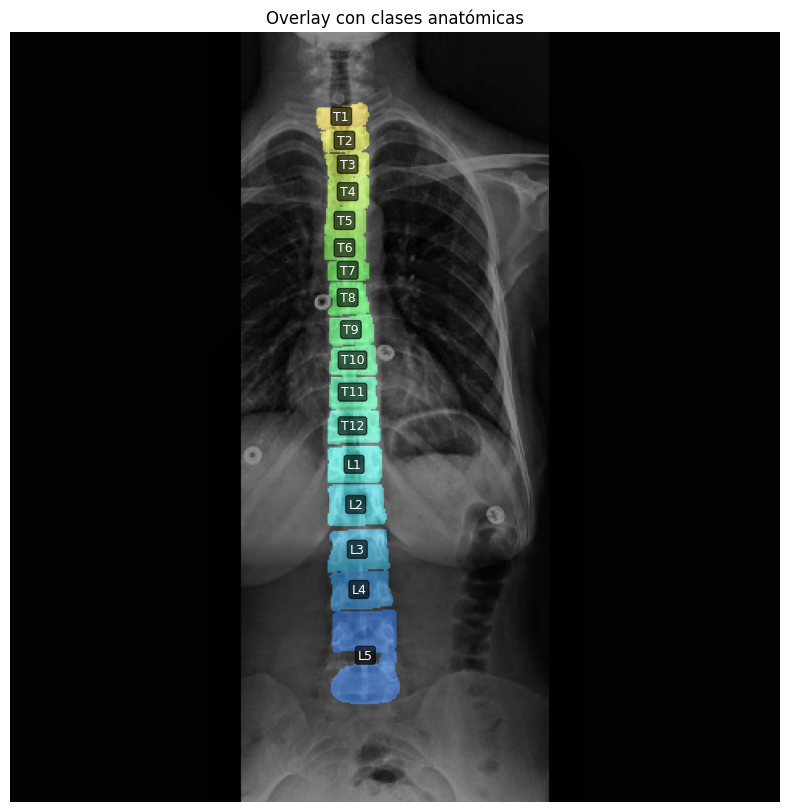

In [24]:
image, mask = val_dataset.__getitem__(0)
print(image.shape)
image = image.permute(1, 2, 0).cpu().numpy()
mask = mask.squeeze().cpu().numpy()
show_overlay_with_labels(image*STD+MEAN, mask, dic_labels)

In [25]:
if MODEL_NAME == 'Unet++':
    model = smp.UnetPlusPlus(
        encoder_name=ENCODER_NAME,
        encoder_weights=ENCODER_WEIGHTS,
        in_channels=IN_CHANNELS,
        classes=NUM_CLASSES,
        decoder_attention_type = DECODER_ATTENTION,
        # pooling='max',
        # dropout = 0.5
    )
elif MODEL_NAME == 'Segformer':
    model = smp.Segformer(
        encoder_name=ENCODER_NAME,
        encoder_weights=ENCODER_WEIGHTS,
        in_channels=IN_CHANNELS,
        classes=NUM_CLASSES,
        # aux_params={'classes':NUM_CLASSES, 'dropout':0.2}
    )
if MODEL_NAME == 'U-net':
    model = smp.Unet(
        encoder_name=ENCODER_NAME,
        encoder_weights=ENCODER_WEIGHTS,
        in_channels=IN_CHANNELS,
        classes=NUM_CLASSES,
        decoder_attention_type = DECODER_ATTENTION,
        # pooling='max',
        # dropout = 0.5
    )


if MODEL_NAME == 'DeepLabV3+':
        model = smp.DeepLabV3Plus(
            encoder_name=ENCODER_NAME,
            encoder_weights=ENCODER_WEIGHTS,
            in_channels=IN_CHANNELS,
            classes=NUM_CLASSES,
            # decoder_attention_type = DECODER_ATTENTION,
            # pooling='max',
            # dropout = 0.5
        )

if DROPOUT is not None:
        model.segmentation_head = nn.Sequential(nn.Dropout2d(p=DROPOUT), model.segmentation_head)
model = model.to(device)

# Definir la función de pérdida y el optimizador
# Usamos BCEWithLogitsLoss porque el modelo no tiene una capa sigmoide final por defecto
# criterion = nn.BCEWithLogitsLoss()

if LOSS == 'CrossEntropyLoss':
    criterion = nn.CrossEntropyLoss()

elif LOSS == 'DiceLoss':
    criterion =  DiceLoss()

elif LOSS == 'CombinedLoss':
    criterion = CombinedLoss()

elif LOSS == 'CombinedLossFocal':
        criterion = CombinedLossFocal()

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WD)

if not TRAIN_ENCODER:
    for param in model.encoder.parameters():
        param.requires_grad = False


# Definir el scheduler
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',    # 'min' porque quieres que la pérdida disminuya
    factor=0.1,    # Reduce el LR al 10% (multiplica por 0.1)
    patience=PATIENCE,    # Espera 5 épocas sin mejora antes de reducir
    threshold=1e-4, # Cambio mínimo para considerar que hay mejora
)

In [26]:
# with mlflow.start_run(experiment_id=experiment.experiment_id):

train_losses = np.zeros(NUM_EPOCHS)
val_losses = np.zeros(NUM_EPOCHS)
val_dice = np.zeros(NUM_EPOCHS)
best_epoch = 0
best_metric = 0
for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0.0

    for images, masks in train_loader:
        images, masks = images.float().to(device), masks.long().to(device) # <--- Asegurar .long()

        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)

        # pred_mask = torch.argmax(outputs, dim=1)
        loss = criterion(outputs, masks)
        # loss = criterion(pred_mask, masks)

        # Backward pass y optimización
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Validación simple
    model.eval()
    val_loss = 0.0
    dice_score_val = torch.empty((0,NUM_CLASSES))
    IoU_score_val = torch.empty((0,NUM_CLASSES))
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.float().to(device), masks.long().to(device)
            outputs = model(images)

            loss = criterion(outputs, masks)
            # loss = criterion(pred_mask, masks)
            val_loss += loss.item()

            pred_mask = torch.argmax(outputs, dim=1)

            dice, IoU = compute_metrics_torch(pred_mask.cpu(), masks.to(torch.long).cpu(), average=False)
            dice_score_val = torch.cat((dice_score_val, dice), dim=0)
            IoU_score_val = torch.cat((IoU_score_val, IoU), dim=0)
        dice_score_val = torch.mean(dice_score_val)
        IoU_score_val = torch.mean(IoU_score_val)

    if dice_score_val > best_metric:
        best_metric = dice_score_val
        torch.save(model.state_dict(), os.path.join('modelos',MODEL_NAME+'.pth'))
        best_epoch = epoch + 1

    train_losses[epoch] = train_loss / len(train_loader)
    val_losses[epoch] = val_loss / len(val_loader)

    scheduler.step(val_loss/len(val_loader))
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f} | Val DICE Score: {dice_score_val:.4f} | Val IoU Score: {IoU_score_val:.4f}")

print('Best Epoch: ', best_epoch, ' Best metric: ', best_metric)

    # mlflow.log_params({'best_epoch': best_epoch, 'EPOCHS': NUM_EPOCHS, 'SEED': SEED, 'BATCH_SIZE': BATCH_SIZE, 'PATIENCE': PATIENCE, 'N_SPLITS': N_SPLITS, 'LR': LR, 'WD': WD, 'IMG_SIZE': IMG_SIZE, 'IN_CHANNELS': IN_CHANNELS, 'TRAIN_ENCODER': TRAIN_ENCODER, 'CENTER_IMAGES': CENTER_IMAGES, 'CLAHE': CLAHE, 'PERSPECTIVE': PERSPECTIVE ,'LOSS': LOSS, 'ENCODER_NAME': ENCODER_NAME, 'DECODER_ATTENTION': DECODER_ATTENTION, 'DROPOUT': DROPOUT})
    #
    # mlflow.log_metric(f"val_mean_dice_score", dice_score_val)
    # mlflow.log_metric(f"best_val_dice_score", dice_score_val)
    # mlflow.pytorch.log_model(model, name=MODEL_NAME)
    #
    # for step, value in enumerate(train_losses):
    #     mlflow.log_metric('train_hist', value, step=step)
    # for step, value in enumerate(val_losses):
    #     mlflow.log_metric('val_hist', value, step=step)


Epoch 1/250 | Train Loss: 3.0444 | Val Loss: 1.4938 | Val DICE Score: 0.0568 | Val IoU Score: 0.0506
Epoch 2/250 | Train Loss: 1.3589 | Val Loss: 1.1128 | Val DICE Score: 0.0545 | Val IoU Score: 0.0535
Epoch 3/250 | Train Loss: 1.1132 | Val Loss: 1.0377 | Val DICE Score: 0.0545 | Val IoU Score: 0.0535
Epoch 4/250 | Train Loss: 1.0678 | Val Loss: 1.0565 | Val DICE Score: 0.0545 | Val IoU Score: 0.0535
Epoch 5/250 | Train Loss: 1.0484 | Val Loss: 1.0564 | Val DICE Score: 0.0545 | Val IoU Score: 0.0535
Epoch 6/250 | Train Loss: 1.0368 | Val Loss: 1.0060 | Val DICE Score: 0.0545 | Val IoU Score: 0.0535
Epoch 7/250 | Train Loss: 1.0327 | Val Loss: 1.0301 | Val DICE Score: 0.0545 | Val IoU Score: 0.0535
Epoch 8/250 | Train Loss: 1.0152 | Val Loss: 1.0305 | Val DICE Score: 0.0545 | Val IoU Score: 0.0535
Epoch 9/250 | Train Loss: 1.0099 | Val Loss: 1.0747 | Val DICE Score: 0.0545 | Val IoU Score: 0.0535
Epoch 10/250 | Train Loss: 1.0050 | Val Loss: 1.1255 | Val DICE Score: 0.0545 | Val IoU Sco

In [37]:
with mlflow.start_run(experiment_id=experiment.experiment_id):
    mlflow.log_params({'best_epoch': best_epoch, 'EPOCHS': NUM_EPOCHS, 'SEED': SEED, 'BATCH_SIZE': BATCH_SIZE, 'PATIENCE': PATIENCE, 'N_SPLITS': N_SPLITS, 'LR': LR, 'WD': WD, 'IMG_SIZE': IMG_SIZE, 'IN_CHANNELS': IN_CHANNELS, 'TRAIN_ENCODER': TRAIN_ENCODER, 'CENTER_IMAGES': CENTER_IMAGES, 'CLAHE': CLAHE, 'PERSPECTIVE': PERSPECTIVE ,'LOSS': LOSS, 'ENCODER_NAME': ENCODER_NAME, 'DECODER_ATTENTION': DECODER_ATTENTION, 'DROPOUT': DROPOUT})

    mlflow.log_metric(f"val_mean_dice_score", best_metric)
    mlflow.log_metric(f"best_val_dice_score", best_metric)
    mlflow.pytorch.log_model(model, name=MODEL_NAME)

    for step, value in enumerate(train_losses):
        mlflow.log_metric('train_hist', value, step=step)
    for step, value in enumerate(val_losses):
        mlflow.log_metric('val_hist', value, step=step)

2026/05/17 02:37:15 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/05/17 02:37:15 WARNING mlflow.utils.requirements_utils: Found torch version (2.7.0+cu118) contains a local version label (+cu118). MLflow logged a pip requirement for this package as 'torch==2.7.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/17 02:37:23 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_e

🏃 View run rebellious-shrew-226 at: https://dbc-250dea69-0463.cloud.databricks.com/ml/experiments/278500065593975/runs/36434b874f6248c4a4ba5a52410d9c8e
🧪 View experiment at: https://dbc-250dea69-0463.cloud.databricks.com/ml/experiments/278500065593975


In [28]:
model.load_state_dict(torch.load(os.path.join('modelos',MODEL_NAME+'.pth'), weights_only=True))
# model = torch.load(MODEL_PATH, weights_only=False)
model.eval()

UnetPlusPlus(
  (encoder): EfficientNetEncoder(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 64, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(64, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_expand_conv): Identity()
        (_bn0): Identity()
        (_depthwise_conv): Conv2dStaticSamePadding(
          64, 64, kernel_size=(3, 3), stride=[1, 1], groups=64, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(64, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          64, 16, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          16, 64, kernel_size=(1, 1), stride=(1, 1)
          (static_padding

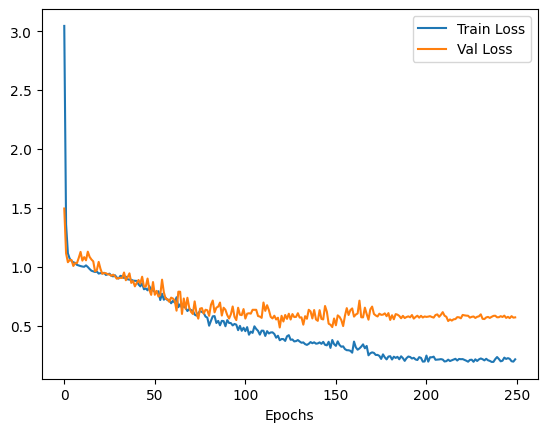

In [29]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel('Epochs')
plt.legend()

In [30]:
dice_score_val = 0
IoU_score_val = 0
model.eval()
with torch.no_grad():
    for idx in range(len(val_dataset)):
            # print(idx)
            image, mask = val_dataset[idx]
            image, mask = image.float().unsqueeze(0).to(device), mask.long().to(device)
            outputs = model(image)
            pred_mask = torch.argmax(outputs, dim=1).squeeze(0).cpu()
            dice, IoU = compute_metrics(pred_mask.cpu().numpy(), mask.to(torch.long).cpu().numpy())
            dice_score_val += dice
            IoU_score_val += IoU

dice_score_val = dice_score_val/len(val_dataset)
IoU_score_val = IoU_score_val/len(val_dataset)

print(f'Mean Dice Score: {dice_score_val} | Mean IoU score: {IoU_score_val}')

Mean Dice Score: 0.6434069077718908 | Mean IoU score: 0.5583869132988398


In [31]:
dice_score_test = np.zeros(NUM_CLASSES)
model.eval()
with torch.no_grad():
    for idx in range(len(test_dataset)):
            image, mask = test_dataset[idx]
            image, mask = image.float().unsqueeze(0).to(device), mask.long().to(device)
            outputs = model(image)
            pred_mask = torch.argmax(outputs, dim=1).squeeze(0).cpu()
            dice, IoU = compute_metrics(pred_mask.cpu().numpy(), mask.to(torch.long).cpu().numpy(), average=False)
            dice_score_test += dice

dice_score_test = dice_score_test/len(test_dataset)

for i,j in zip(dic_labels['mascara_multiclase_id_png'], dice_score_test):
    print(dic_labels['mascara_multiclase_id_png'][i],f'{j:.4f}')

background 0.9890
T1 0.5524
T2 0.6031
T3 0.6315
T4 0.6195
T5 0.6516
T6 0.6179
T7 0.5411
T8 0.4648
T9 0.3812
T10 0.3582
T11 0.4423
T12 0.6233
L1 0.6976
L2 0.5569
L3 0.5536
L4 0.4482
L5 0.3752


Text(0, 0.5, 'mean DICE score')

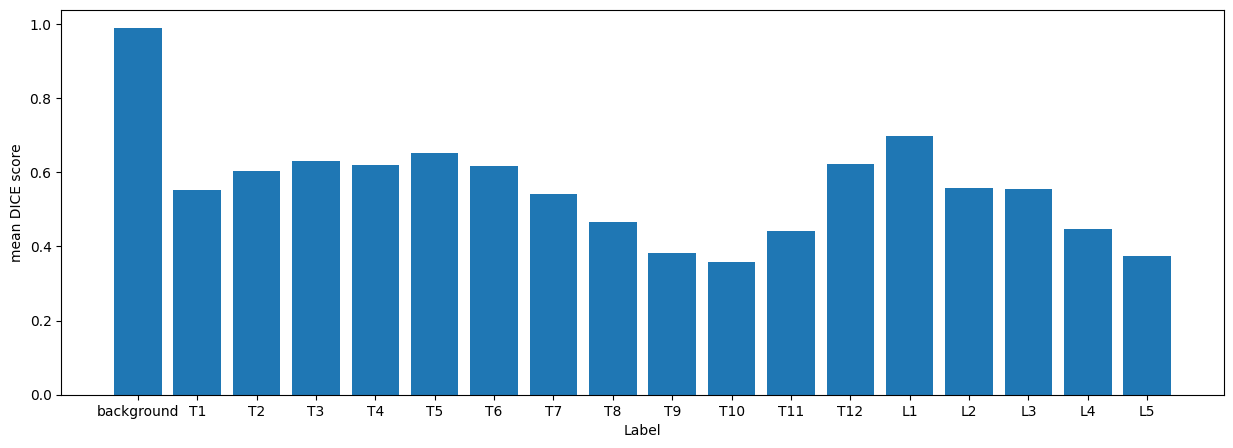

In [32]:
x = range(len(dice_score_test))
f, ax = plt.subplots()
ax.bar(x, dice_score_test)
ax.set_xticks(x)
labels = [dic_labels['mascara_multiclase_id_png'][i] for i  in dic_labels['mascara_multiclase_id_png']]
ax.set_xticklabels(labels)
ax.figure.set_size_inches(15, 5)
ax.set_xlabel('Label')
ax.set_ylabel('mean DICE score')

In [33]:
dice_score_test = torch.zeros(NUM_CLASSES)
model.eval()
with torch.no_grad():
    for idx in range(len(test_dataset)):
            image, mask = test_dataset[idx]
            image, mask = image.unsqueeze(0).float().to(device), mask.unsqueeze(0).long().to(device)
            outputs = model(image)
            pred_mask = torch.argmax(outputs, dim=1).cpu()
            dice, IoU = compute_metrics_torch(pred_mask.cpu(), mask.to(torch.long).cpu(), average=False)
            dice_score_test += dice.squeeze(0)

dice_score_test = dice_score_test/len(test_dataset)
print(f'Mean Dice Score: {torch.mean(dice_score_test):.4f}')


for i,j in zip(dic_labels['mascara_multiclase_id_png'], dice_score_test):
    print(dic_labels['mascara_multiclase_id_png'][i],f'{j:.4f}')

Mean Dice Score: 0.5776
background 0.9899
T1 0.5634
T2 0.6104
T3 0.6320
T4 0.5704
T5 0.6147
T6 0.5977
T7 0.5368
T8 0.4699
T9 0.4041
T10 0.4344
T11 0.5592
T12 0.6500
L1 0.7254
L2 0.5853
L3 0.5890
L4 0.4815
L5 0.3822


In [34]:
dice_score_test = torch.empty((0,18))
with torch.no_grad():
        for images, masks in test_loader:
            images, masks = images.float().to(device), masks.long().to(device)
            # print(images.shape, masks.shape)
            outputs = model(images)
            pred_mask = torch.argmax(outputs, dim=1)
            dice, IoU = compute_metrics_torch(pred_mask.cpu(), masks.to(torch.long).cpu(), average=False)
            # print(dice.shape)
            dice_score_test = torch.cat((dice_score_test, dice), dim=0)

print(f'Mean Dice Score: {torch.mean(dice_score_test):.4f}')
mean_dice_score = torch.mean(dice_score_test, dim=0).numpy()

for i,j in zip(dic_labels['mascara_multiclase_id_png'], mean_dice_score):
    print(dic_labels['mascara_multiclase_id_png'][i],f'{j:.4f}')

Mean Dice Score: 0.5586
background 0.9891
T1 0.5326
T2 0.5869
T3 0.6212
T4 0.6084
T5 0.6459
T6 0.6144
T7 0.5289
T8 0.4542
T9 0.4048
T10 0.3672
T11 0.4537
T12 0.6014
L1 0.7093
L2 0.5624
L3 0.5567
L4 0.4540
L5 0.3637


In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

def build_color_map_from_json(label_dict):
    color_map_raw = label_dict["mascara_multiclase_color_rgb"]
    return {int(k): tuple(v) for k, v in color_map_raw.items()}

def build_label_map_from_json(label_dict):
    label_map_raw = label_dict["mascara_multiclase_id_png"]
    return {int(k): v for k, v in label_map_raw.items()}

def create_color_overlay(mask, color_map):
    h, w = mask.shape
    overlay = np.zeros((h, w, 3), dtype=np.uint8)

    for class_id, color in color_map.items():
        overlay[mask == class_id] = color

    return overlay

def get_class_centroid(mask, class_id):
    ys, xs = np.where(mask == class_id)
    if len(xs) == 0 or len(ys) == 0:
        return None
    cx = int(np.mean(xs))
    cy = int(np.mean(ys))
    return cx, cy

def draw_labels_on_axis(ax, mask, label_map, min_pixels=20):
    unique_vals = np.unique(mask)

    for class_id in unique_vals:
        if class_id == 0:
            continue

        region = (mask == class_id)
        if region.sum() < min_pixels:
            continue

        centroid = get_class_centroid(mask, class_id)
        if centroid is None:
            continue

        x, y = centroid
        class_name = label_map.get(int(class_id), str(class_id))

        ax.text(
            x, y, class_name,
            fontsize=9,
            ha="center",
            va="center",
            color="white",
            bbox=dict(facecolor="black", alpha=0.6, boxstyle="round,pad=0.2")
        )

def show_gt_vs_pred_with_labels(
    model,
    dataset,
    device,
    idx,
    label_dict,
    alpha=0.45,
    min_pixels=20
):
    model.eval()

    label_map = build_label_map_from_json(label_dict)
    color_map = build_color_map_from_json(label_dict)

    print(dataset.__getpath__(idx))

    sample = dataset[idx]
    if sample is None:
        print(f"No se pudo cargar la muestra {idx}")
        return

    image_tensor, gt_mask = sample
    image_batch = image_tensor.float().unsqueeze(0).to(device)

    with torch.no_grad():
        if device.type == "cuda":
            with torch.amp.autocast(device_type="cuda"):
                logits = model(image_batch)
        else:
            logits = model(image_batch)

    pred_mask = torch.argmax(logits, dim=1).squeeze(0).cpu()

    # dice_score = DiceScore(num_classes=NUM_CLASSES, average="none", input_format='index')
    # dice_score_mean = DiceScore(num_classes=NUM_CLASSES, average="macro", input_format='index')
    # dice_score_mean = dice_score_mean(pred_mask, gt_mask.to(torch.long).cpu())
    # sample_dice = dice_score(pred_mask, gt_mask.to(torch.long).cpu())

    pred_mask = pred_mask.numpy()
    gt_mask = gt_mask.cpu().numpy()

    sample_dice, sample_IoU = compute_metrics(pred_mask, gt_mask, average=False)
    dice_score_mean, IoU_score_mean = compute_metrics(pred_mask, gt_mask)

    image = image_tensor.cpu().numpy()
    if image.shape[0] == 1:
        image = image.squeeze(0)
        image_cmap = "gray"
    else:
        image = np.transpose(image, (1, 2, 0))
        image_cmap = None

    # image = np.clip(image, 0, 1)
    image = image*STD+MEAN

    gt_overlay = create_color_overlay(gt_mask, color_map)
    pred_overlay = create_color_overlay(pred_mask, color_map)

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    axes[0].imshow(image, cmap=image_cmap)
    axes[0].set_title("Imagen")
    axes[0].axis("off")

    axes[1].imshow(image, cmap=image_cmap)
    axes[1].imshow(gt_overlay, alpha=alpha)
    draw_labels_on_axis(axes[1], gt_mask, label_map, min_pixels=min_pixels)
    axes[1].set_title("Ground Truth con etiquetas")
    axes[1].axis("off")

    axes[2].imshow(image, cmap=image_cmap)
    axes[2].imshow(pred_overlay, alpha=alpha)
    draw_labels_on_axis(axes[2], pred_mask, label_map, min_pixels=min_pixels)
    axes[2].set_title(f"Predicción con etiquetas, Dice={dice_score_mean:.4f}")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    gt_classes = np.unique(gt_mask)
    pred_classes = np.unique(pred_mask)
    # print(f'Dice Score promedio: {dice_score_mean.numpy():.4f}')
    print(f'Dice Score promedio: {dice_score_mean:.4f}')
    print('Dice Score por clase: ')
    for i,j in zip(dic_labels['mascara_multiclase_id_png'], sample_dice):
        # print(dic_labels['mascara_multiclase_id_png'][i],j.numpy())
        print(dic_labels['mascara_multiclase_id_png'][i],f'{j:.4f}')
    # print(f"DICE Score: {sample_dice:.4f}")

    # print("\nClases presentes en Ground Truth:")
    # for c in gt_classes:
    #     name = label_map.get(int(c), f"Clase {c}")
    #     print(f"  {c} → {name}")
    #
    # print("\nClases presentes en Predicción:")
    # for c in pred_classes:
    #     name = label_map.get(int(c), f"Clase {c}")
    #     print(f"  {c} → {name}")

0
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset_v2\Normal/N_1.jpg


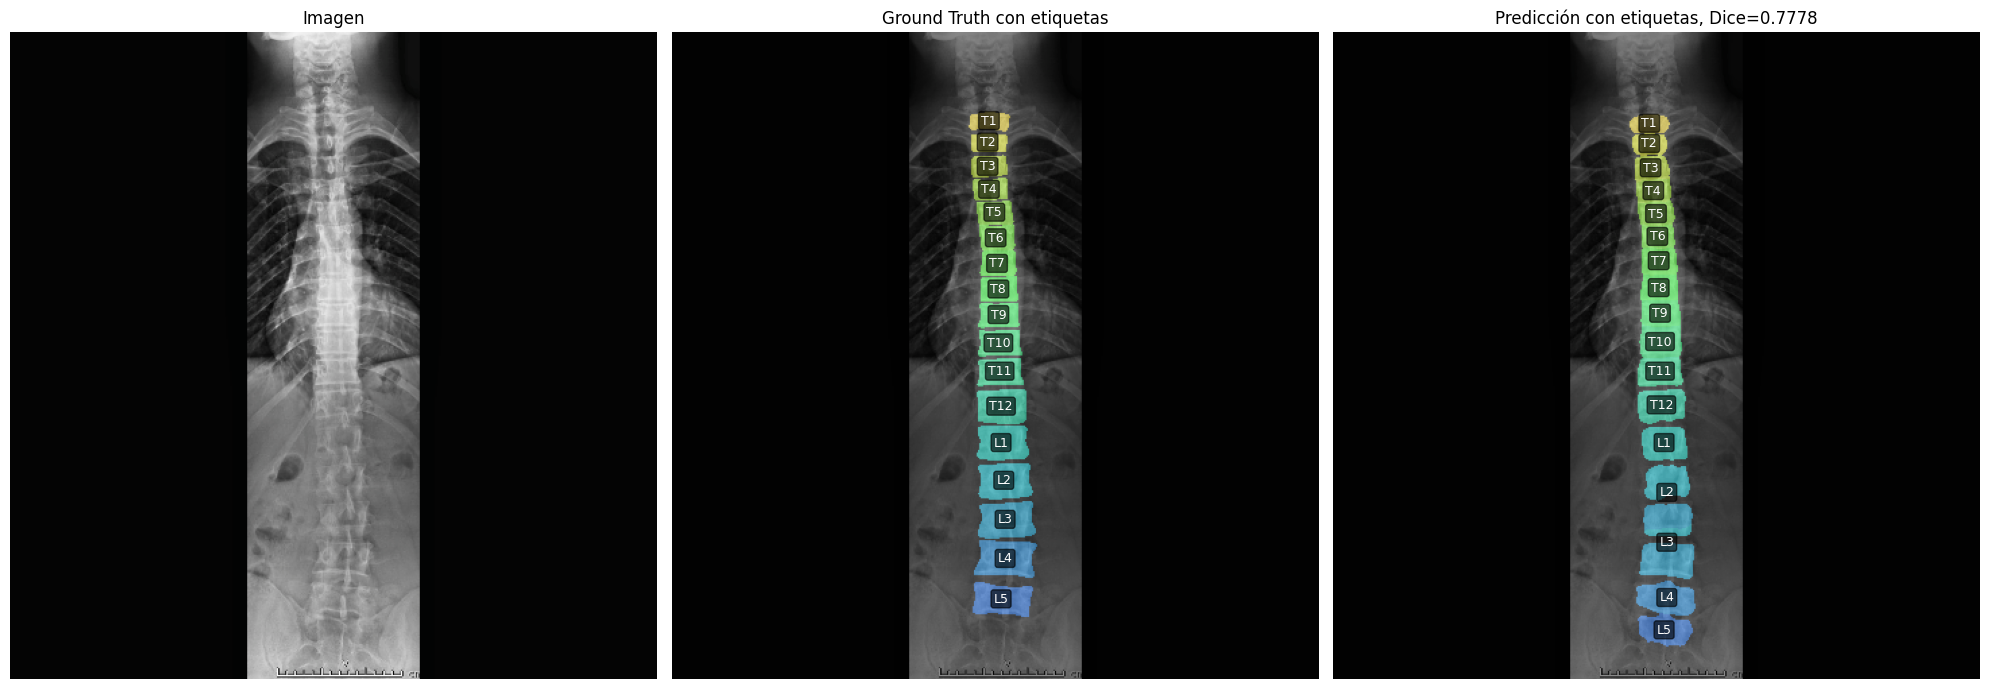

Dice Score promedio: 0.7778
Dice Score por clase: 
background 0.9942
T1 0.8182
T2 0.9059
T3 0.8707
T4 0.8733
T5 0.9567
T6 0.9190
T7 0.9198
T8 0.9156
T9 0.9074
T10 0.8826
T11 0.9397
T12 0.9209
L1 0.9183
L2 0.7692
L3 0.4850
L4 0.0000
L5 0.0036
1
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset_v2\Normal/N_6.jpg


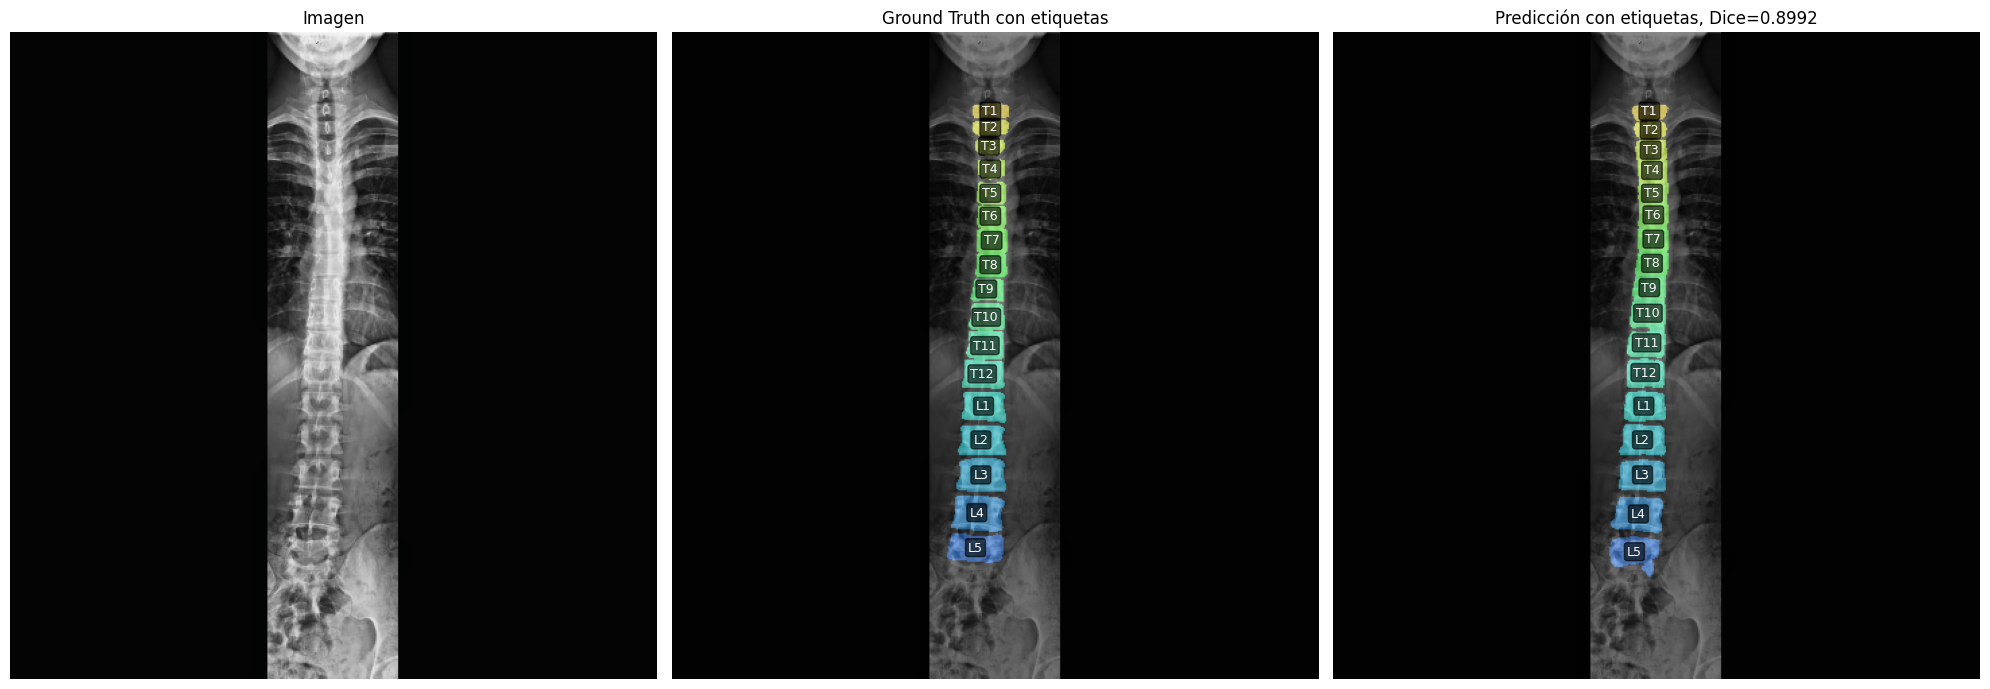

Dice Score promedio: 0.8992
Dice Score por clase: 
background 0.9969
T1 0.8743
T2 0.8414
T3 0.8021
T4 0.8267
T5 0.9402
T6 0.9144
T7 0.9367
T8 0.9113
T9 0.8676
T10 0.8422
T11 0.8875
T12 0.9370
L1 0.9474
L2 0.9704
L3 0.9446
L4 0.9470
L5 0.7972
2
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset_v2\Normal/N_47.jpg


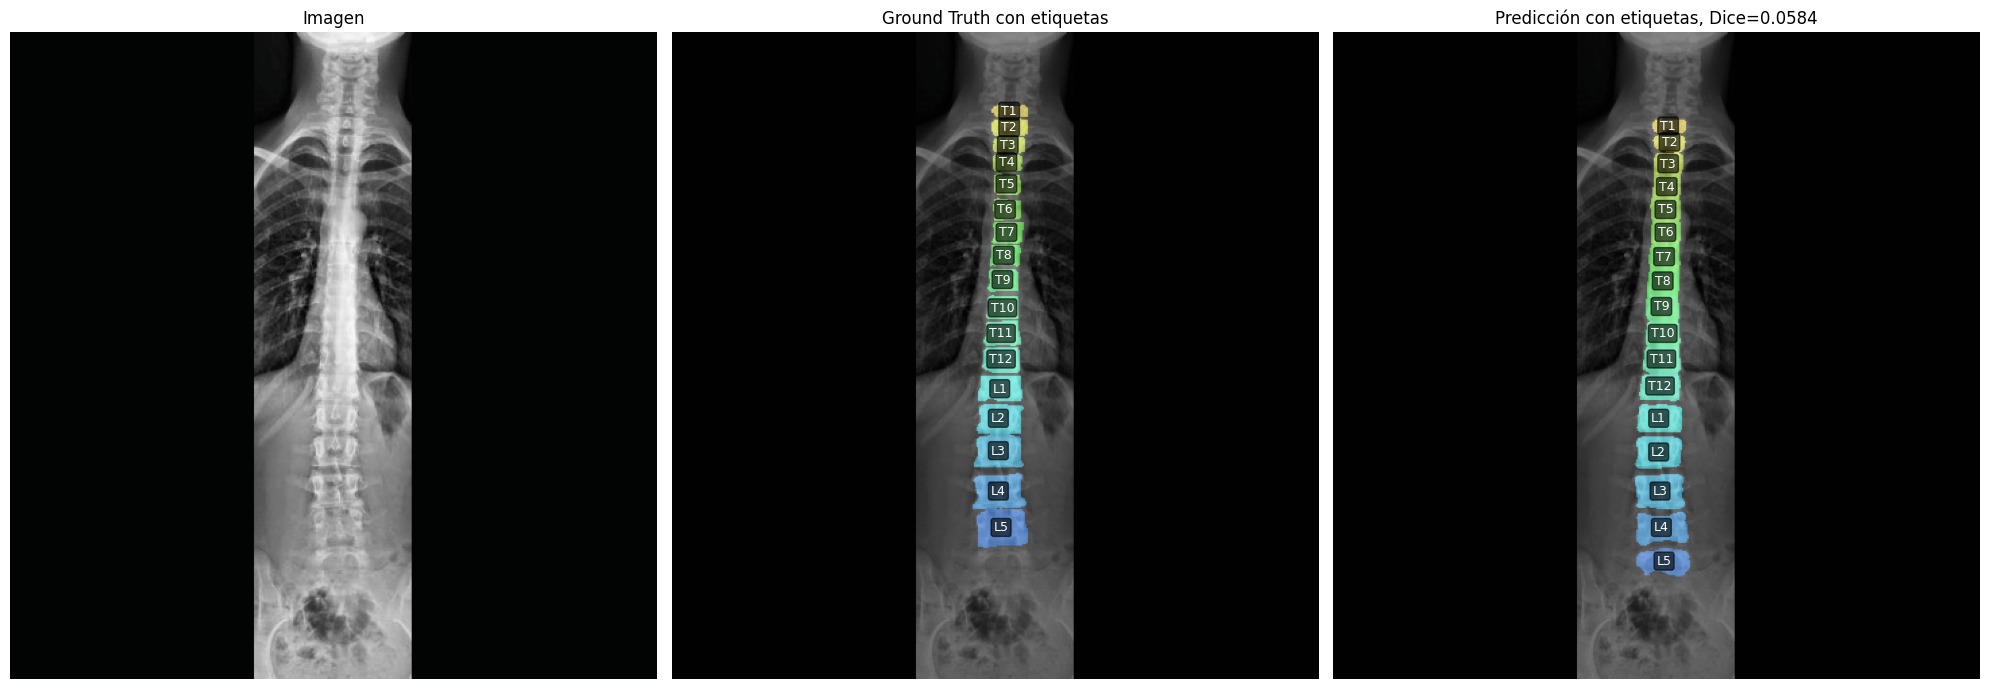

Dice Score promedio: 0.0584
Dice Score por clase: 
background 0.9946
T1 0.0000
T2 0.0571
T3 0.0000
T4 0.0000
T5 0.0000
T6 0.0000
T7 0.0000
T8 0.0000
T9 0.0000
T10 0.0000
T11 0.0000
T12 0.0000
L1 0.0000
L2 0.0000
L3 0.0000
L4 0.0000
L5 0.0000
3
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset_v2\Normal/N_15.jpg


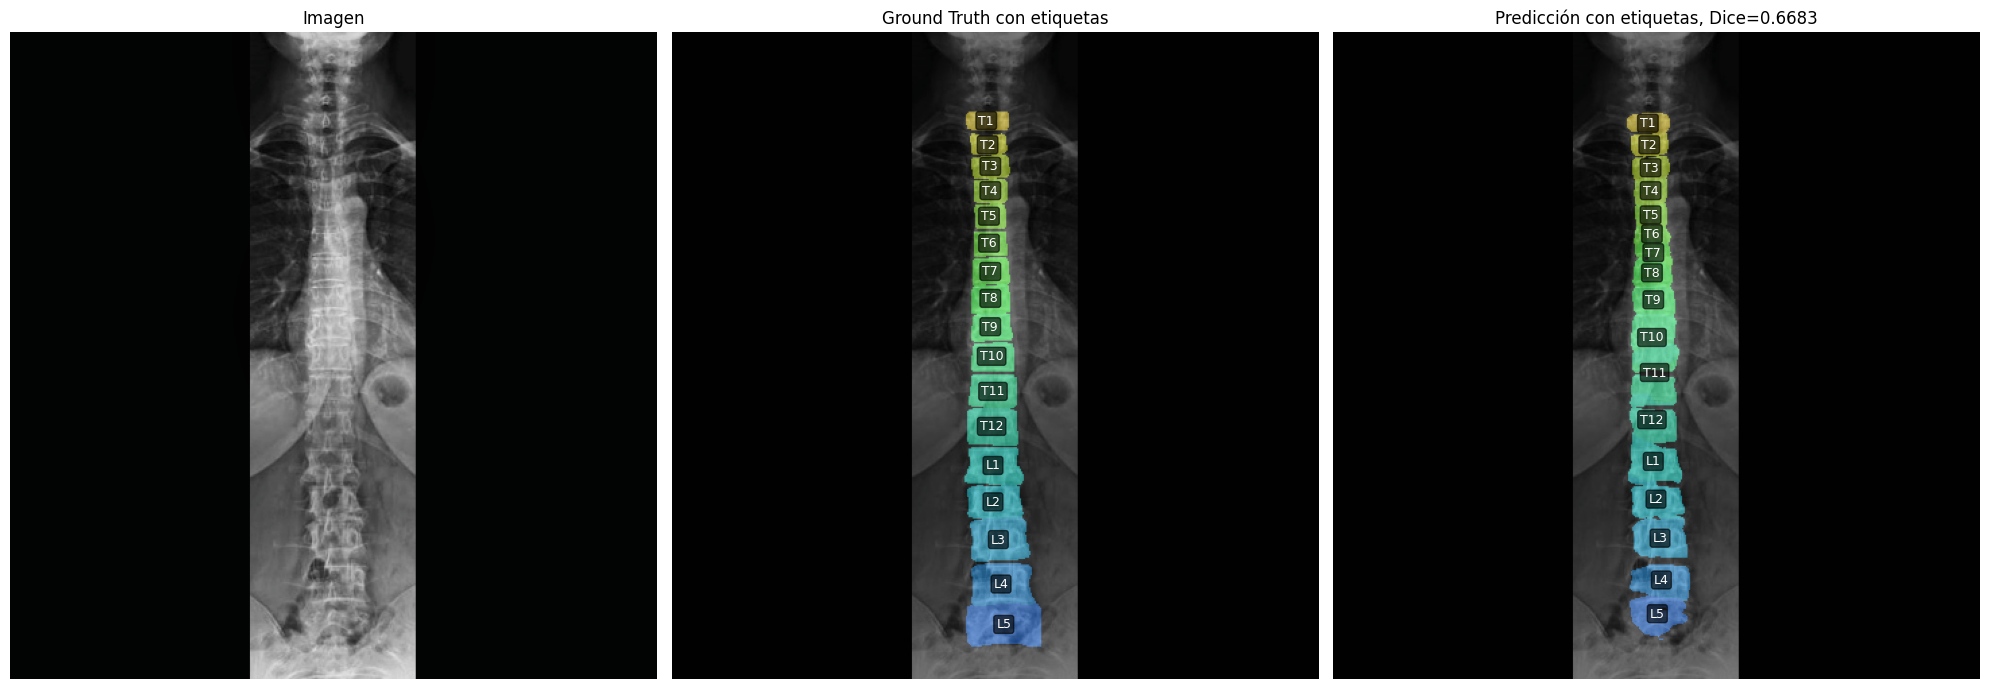

Dice Score promedio: 0.6683
Dice Score por clase: 
background 0.9941
T1 0.8776
T2 0.9294
T3 0.9387
T4 0.9333
T5 0.9189
T6 0.4783
T7 0.1661
T8 0.0329
T9 0.0082
T10 0.3327
T11 0.5941
T12 0.7846
L1 0.8546
L2 0.8824
L3 0.9076
L4 0.8222
L5 0.5733
4
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset_v2\Normal/N_57.jpg


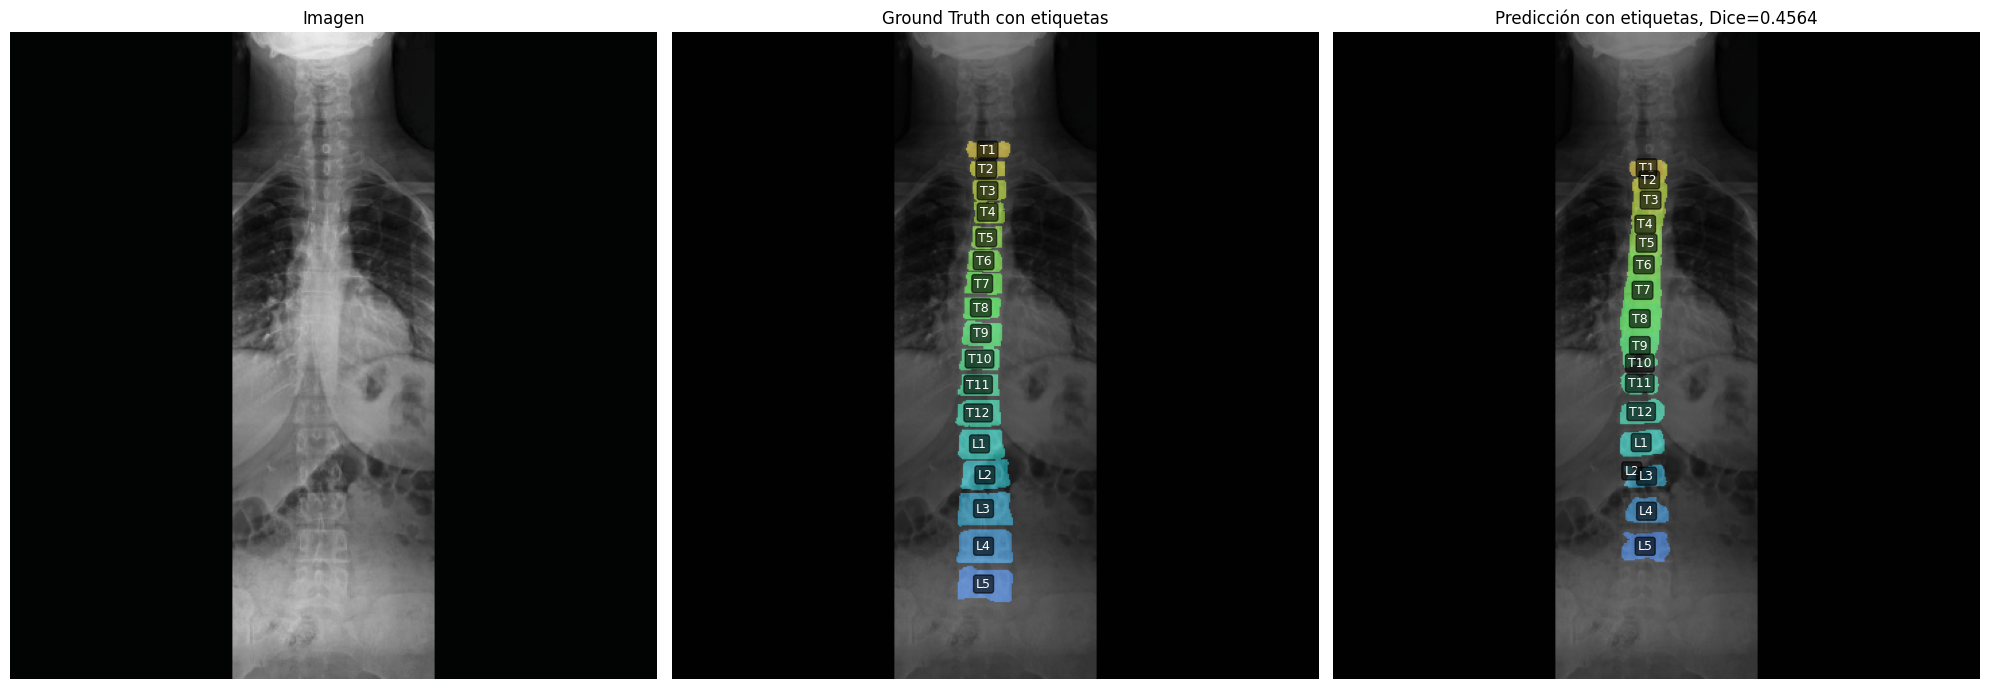

Dice Score promedio: 0.4564
Dice Score por clase: 
background 0.9919
T1 0.0000
T2 0.0835
T3 0.5975
T4 0.4342
T5 0.5874
T6 0.7466
T7 0.6492
T8 0.5176
T9 0.4769
T10 0.4283
T11 0.8725
T12 0.8683
L1 0.8891
L2 0.0718
L3 0.0000
L4 0.0000
L5 0.0000
5
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset_v2\Normal/N_65.jpg


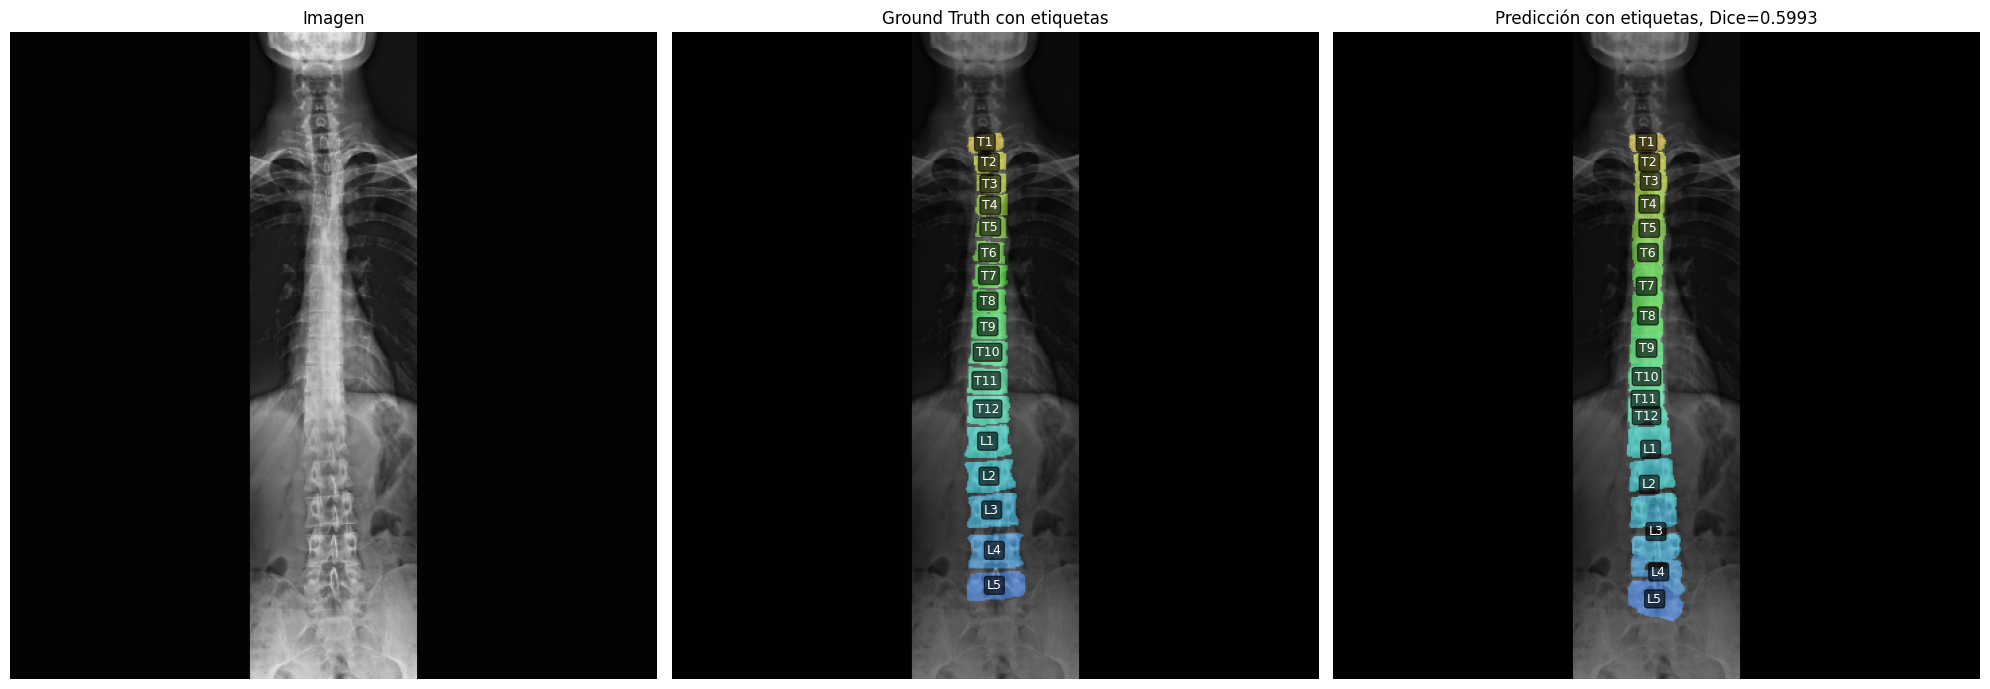

Dice Score promedio: 0.5993
Dice Score por clase: 
background 0.9945
T1 0.9374
T2 0.8935
T3 0.8515
T4 0.7809
T5 0.8143
T6 0.8478
T7 0.6531
T8 0.3211
T9 0.1718
T10 0.0146
T11 0.2118
T12 0.6426
L1 0.8284
L2 0.6131
L3 0.4759
L4 0.2292
L5 0.5057
6
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset_v2\Scoliosis/S_91.jpg


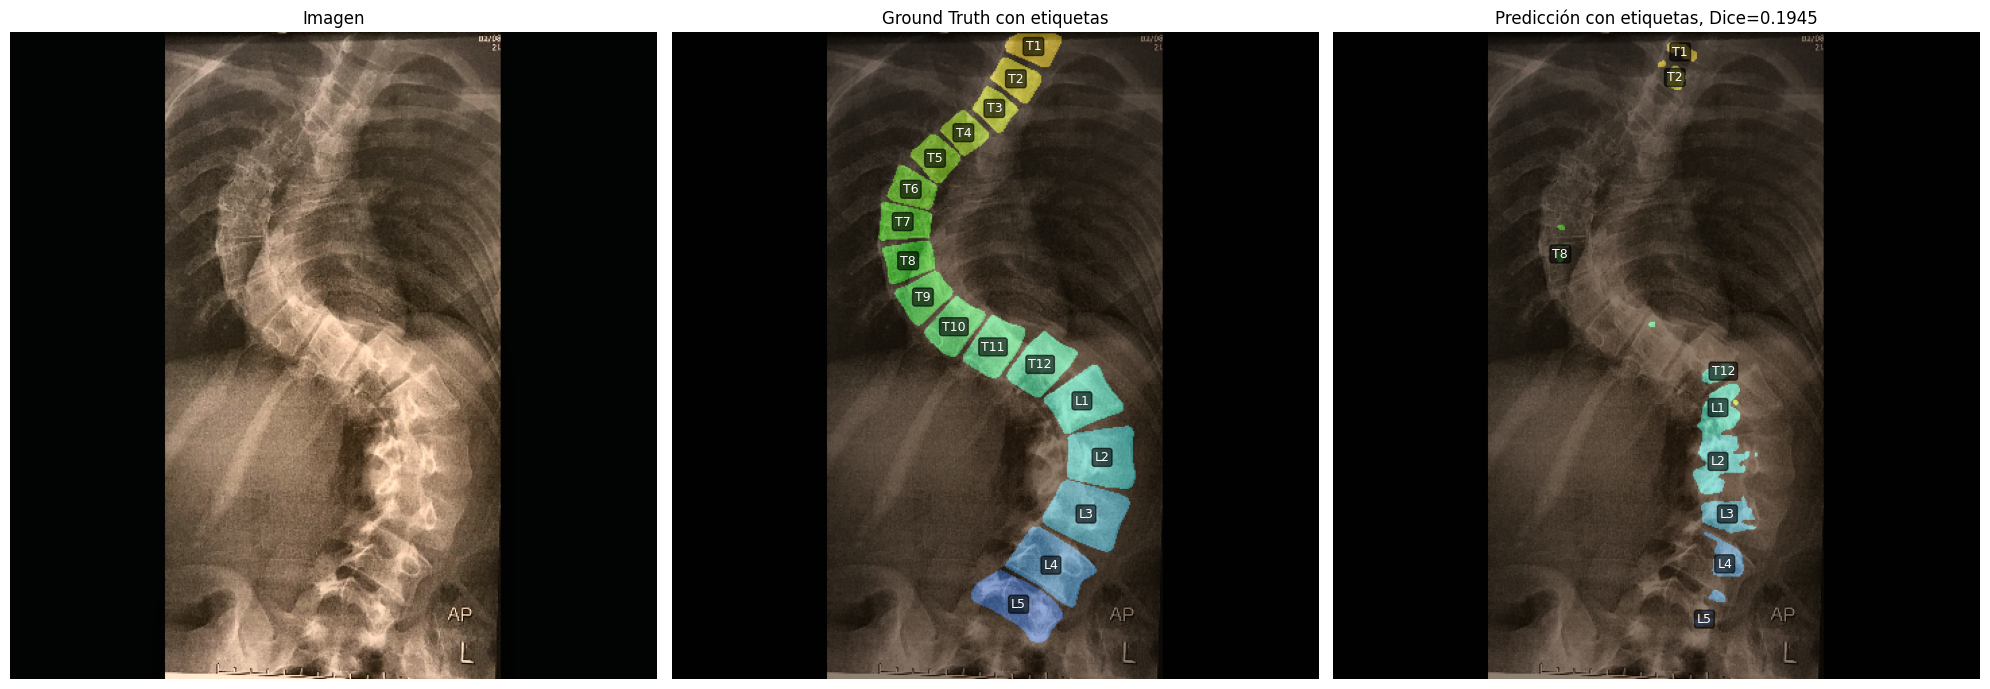

Dice Score promedio: 0.1945
Dice Score por clase: 
background 0.9546
T1 0.3438
T2 0.3929
T3 0.0000
T4 0.0000
T5 0.0000
T6 0.0000
T7 0.0407
T8 0.1056
T9 0.0000
T10 0.0000
T11 0.0272
T12 0.0880
L1 0.4089
L2 0.1615
L3 0.4632
L4 0.4226
L5 0.0915
7
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset_v2\Scoliosis/S_94.jpg


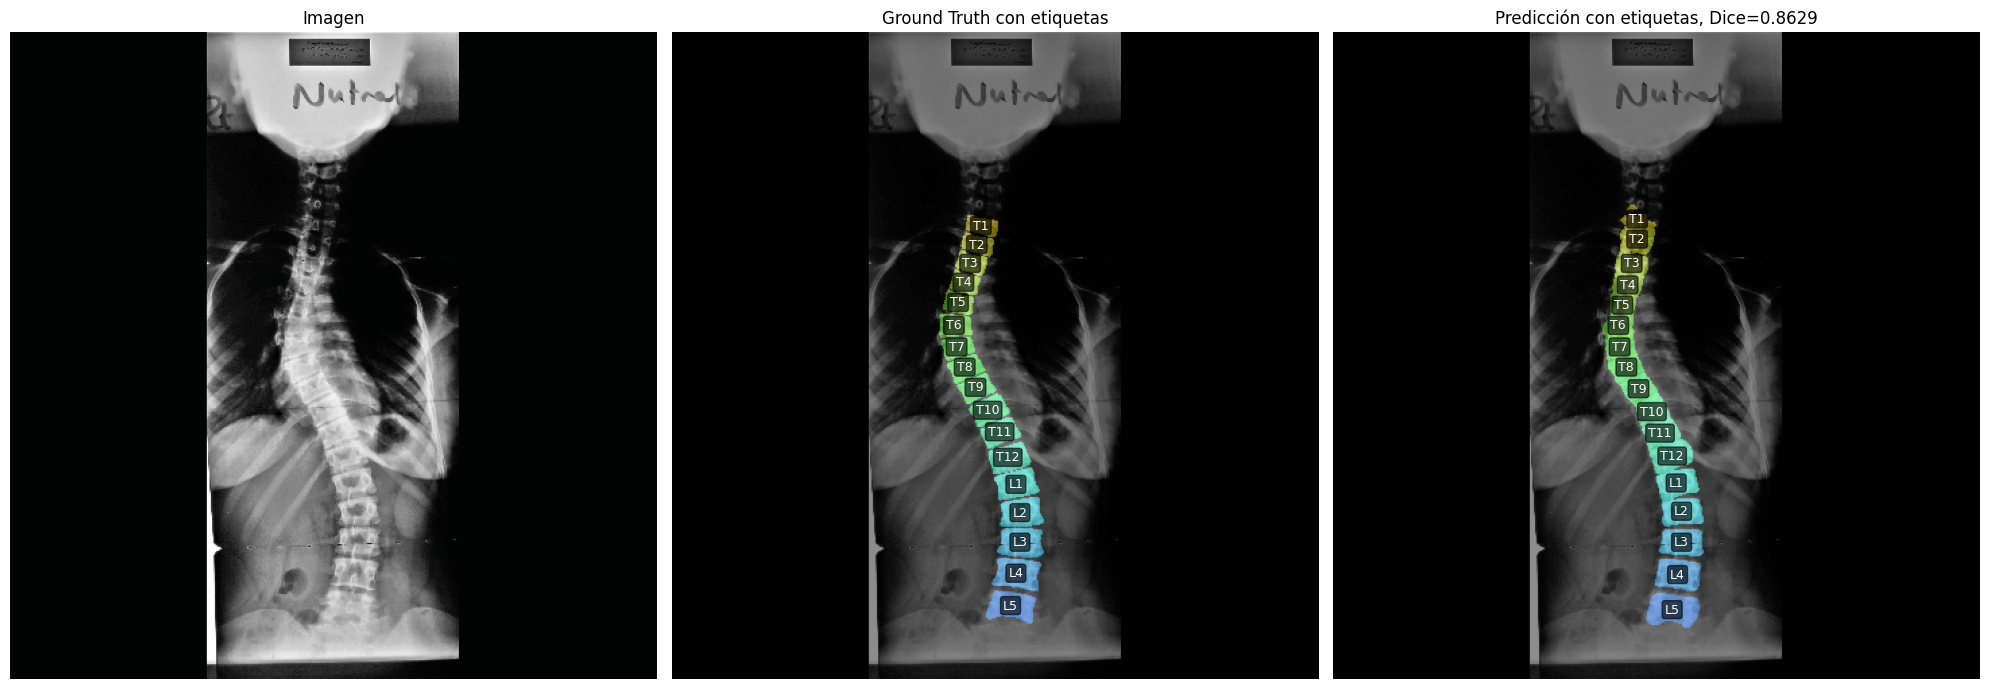

Dice Score promedio: 0.8629
Dice Score por clase: 
background 0.9966
T1 0.5720
T2 0.7122
T3 0.9043
T4 0.8584
T5 0.8190
T6 0.8830
T7 0.8829
T8 0.8792
T9 0.8252
T10 0.8255
T11 0.9120
T12 0.8796
L1 0.9391
L2 0.9343
L3 0.9368
L4 0.9358
L5 0.8368


In [36]:
import random
# Seleccionar un índice aleatorio del dataset de test
# idx = random.randint(0, len(test_dataset) - 1)
# print(idx)
for idx in range(len(test_dataset)):
    print(idx)
    show_gt_vs_pred_with_labels(
        model=model,
        dataset=test_dataset,
        device=device,
        idx=idx,
        label_dict=dic_labels,
        alpha=0.45,
        min_pixels=20
    )